In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aartipandey23/toughest-sport/toughest_sport.xlsx


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
sns.set_style("whitegrid")
pd.set_option("display.max_columns",None)

In [3]:
df=pd.read_excel('/kaggle/input/datasets/aartipandey23/toughest-sport/toughest_sport.xlsx')

In [4]:
df.head()


,Sport,Endurance,Strength,Power,Speed,Agility,Flexibility,Nerve,Durability,Hand-Eye Coordination,Analytical Aptitude,Total,Rank
0,Boxing,8.63,8.13,8.63,6.38,6.25,4.38,8.88,8.50,7.00,5.63,72.375,1
1,Ice Hockey,7.25,7.13,7.88,7.75,7.63,4.88,6.00,8.25,7.50,7.50,71.750,2
2,Football,5.38,8.63,8.13,7.13,6.38,4.38,7.25,8.50,5.50,7.13,68.375,3
3,Basketball,7.38,6.25,6.50,7.25,8.13,5.63,4.13,7.75,7.50,7.38,67.875,4
4,Wrestling,6.63,8.38,7.13,5.13,6.38,7.50,5.00,6.75,4.25,6.38,63.500,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sport                  60 non-null     object 
 1   Endurance              60 non-null     float64
 2   Strength               60 non-null     float64
 3   Power                  60 non-null     float64
 4   Speed                  60 non-null     float64
 5   Agility                60 non-null     float64
 6   Flexibility            60 non-null     float64
 7   Nerve                  60 non-null     float64
 8   Durability             60 non-null     float64
 9   Hand-Eye Coordination  60 non-null     float64
 10  Analytical Aptitude    60 non-null     float64
 11  Total                  60 non-null     float64
 12  Rank                   60 non-null     int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 6.2+ KB


In [6]:
df.describe()

,Endurance,Strength,Power,Speed,Agility,Flexibility,Nerve,Durability,Hand-Eye Coordination,Analytical Aptitude,Total,Rank
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,5.077667,5.169000,5.509167,4.815000,4.765000,4.723167,4.614833,4.612833,4.954833,4.767333,48.983333,30.400000
std,2.094217,1.715357,1.980397,2.266403,1.927273,1.704369,2.442645,1.882102,1.966328,1.576830,12.170519,17.473661
min,1.000000,1.000000,1.250000,0.630000,1.000000,1.130000,0.880000,0.750000,1.880000,2.250000,14.500000,1.000000
25%,3.500000,3.880000,4.097500,3.000000,3.437500,3.847500,2.597500,3.380000,3.130000,3.437500,44.093750,15.750000
50%,4.630000,5.190000,5.690000,5.130000,4.755000,4.750000,4.190000,4.630000,4.440000,4.250000,48.000000,30.000000
75%,6.660000,6.130000,7.130000,6.410000,6.380000,5.532500,6.532500,5.782500,6.630000,6.160000,56.031250,45.250000
max,9.630000,9.250000,9.750000,9.880000,8.250000,10.000000,9.880000,8.500000,9.250000,7.500000,72.375000,60.000000


In [7]:
df.isna().sum()

Sport                    0
Endurance                0
Strength                 0
Power                    0
Speed                    0
Agility                  0
Flexibility              0
Nerve                    0
Durability               0
Hand-Eye Coordination    0
Analytical Aptitude      0
Total                    0
Rank                     0
dtype: int64

In [8]:
top10=df.sort_values(by='Total',ascending=False).head(10)
top10

,Sport,Endurance,Strength,Power,Speed,Agility,Flexibility,Nerve,Durability,Hand-Eye Coordination,Analytical Aptitude,Total,Rank
0,Boxing,8.63,8.13,8.63,6.38,6.25,4.38,8.88,8.50,7.00,5.63,72.375,1
1,Ice Hockey,7.25,7.13,7.88,7.75,7.63,4.88,6.00,8.25,7.50,7.50,71.750,2
2,Football,5.38,8.63,8.13,7.13,6.38,4.38,7.25,8.50,5.50,7.13,68.375,3
3,Basketball,7.38,6.25,6.50,7.25,8.13,5.63,4.13,7.75,7.50,7.38,67.875,4
4,Wrestling,6.63,8.38,7.13,5.13,6.38,7.50,5.00,6.75,4.25,6.38,63.500,5
5,Martial Arts,5.00,5.88,7.75,6.38,6.00,7.00,6.63,5.88,6.00,6.88,63.375,6
6,Tennis,7.25,5.13,7.13,6.75,7.75,5.63,3.00,5.00,8.38,6.75,62.750,7
7,Gymnastics,5.38,6.13,6.63,5.00,6.38,10.00,7.50,6.88,4.50,4.13,62.500,8
8,Baseball/Softball,4.63,5.75,7.63,6.50,6.75,4.75,5.13,5.63,9.25,6.25,62.250,9
9,Soccer,7.75,4.50,5.13,7.25,8.25,4.75,3.63,6.25,6.50,7.50,61.500,10


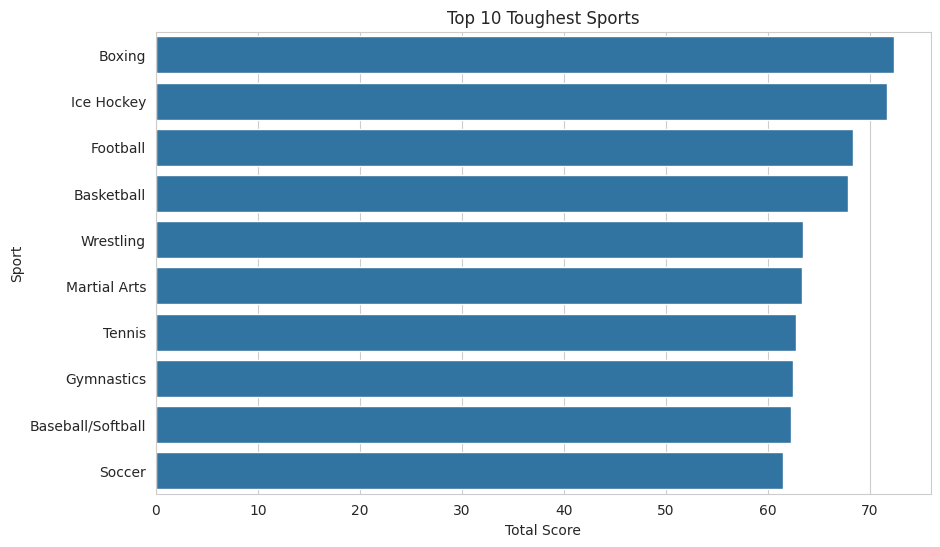

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Total',
    y='Sport'
)

plt.title('Top 10 Toughest Sports')
plt.xlabel('Total Score')
plt.ylabel('Sport')

plt.show()

In [10]:
numeric_df=df.select_dtypes(include='number')
numeric_df.head()

,Endurance,Strength,Power,Speed,Agility,Flexibility,Nerve,Durability,Hand-Eye Coordination,Analytical Aptitude,Total,Rank
0,8.63,8.13,8.63,6.38,6.25,4.38,8.88,8.50,7.00,5.63,72.375,1
1,7.25,7.13,7.88,7.75,7.63,4.88,6.00,8.25,7.50,7.50,71.750,2
2,5.38,8.63,8.13,7.13,6.38,4.38,7.25,8.50,5.50,7.13,68.375,3
3,7.38,6.25,6.50,7.25,8.13,5.63,4.13,7.75,7.50,7.38,67.875,4
4,6.63,8.38,7.13,5.13,6.38,7.50,5.00,6.75,4.25,6.38,63.500,5


In [11]:
corr=numeric_df.corr()
corr

,Endurance,Strength,Power,Speed,Agility,Flexibility,Nerve,Durability,Hand-Eye Coordination,Analytical Aptitude,Total,Rank
Endurance,1.000000,0.465957,0.331431,0.508998,0.404104,0.166356,0.036551,0.612059,0.032386,0.301490,0.620007,-0.568893
Strength,0.465957,1.000000,0.853117,0.473869,0.302558,0.284588,0.326709,0.708233,-0.162232,-0.052822,0.677928,-0.586418
Power,0.331431,0.853117,1.000000,0.621509,0.437006,0.344320,0.169321,0.539807,0.043739,0.045420,0.703548,-0.628452
Speed,0.508998,0.473869,0.621509,1.000000,0.656815,0.397697,0.033559,0.500793,0.075236,0.165312,0.719203,-0.683404
Agility,0.404104,0.302558,0.437006,0.656815,1.000000,0.592108,0.215420,0.573332,0.495100,0.478133,0.820605,-0.817967
Flexibility,0.166356,0.284588,0.344320,0.397697,0.592108,1.000000,0.245350,0.357917,-0.024113,-0.020184,0.530648,-0.496767
Nerve,0.036551,0.326709,0.169321,0.033559,0.215420,0.245350,1.000000,0.596261,0.028128,0.135726,0.469579,-0.440640
Durability,0.612059,0.708233,0.539807,0.500793,0.573332,0.357917,0.596261,1.000000,0.084581,0.301489,0.854064,-0.792038
Hand-Eye Coordination,0.032386,-0.162232,0.043739,0.075236,0.495100,-0.024113,0.028128,0.084581,1.000000,0.727969,0.353430,-0.403865
Analytical Aptitude,0.301490,-0.052822,0.045420,0.165312,0.478133,-0.020184,0.135726,0.301489,0.727969,1.000000,0.476560,-0.532069


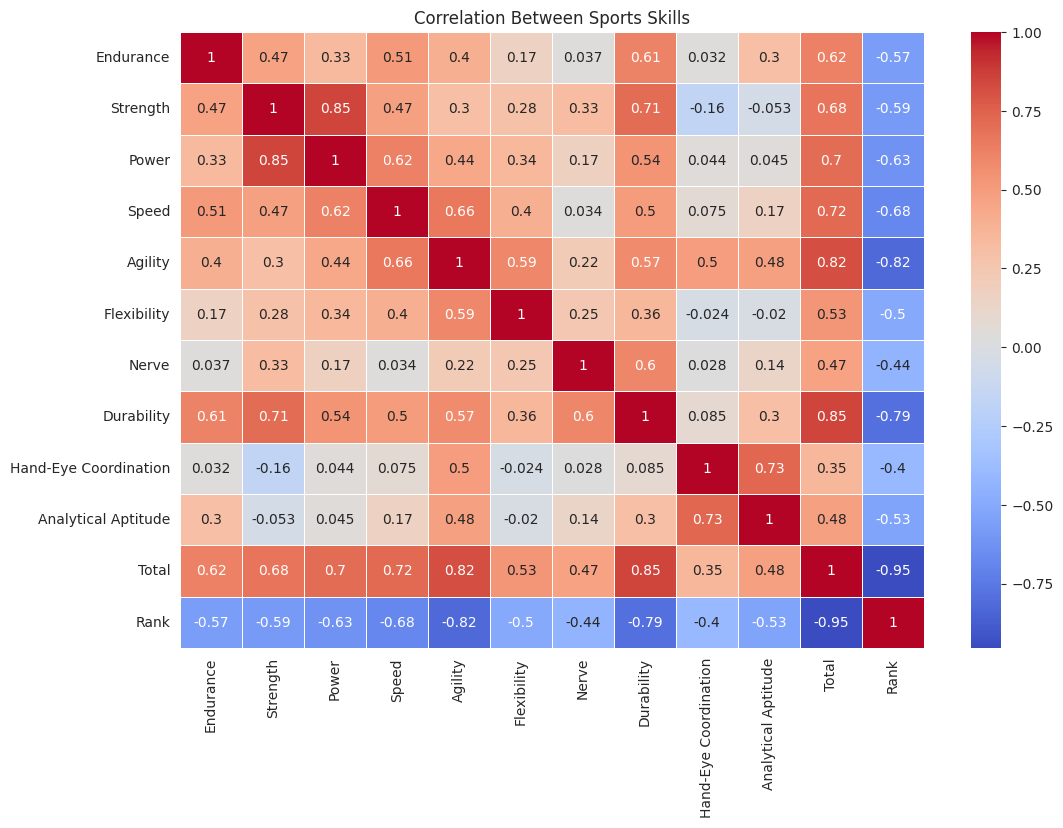

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Between Sports Skills")

plt.show()

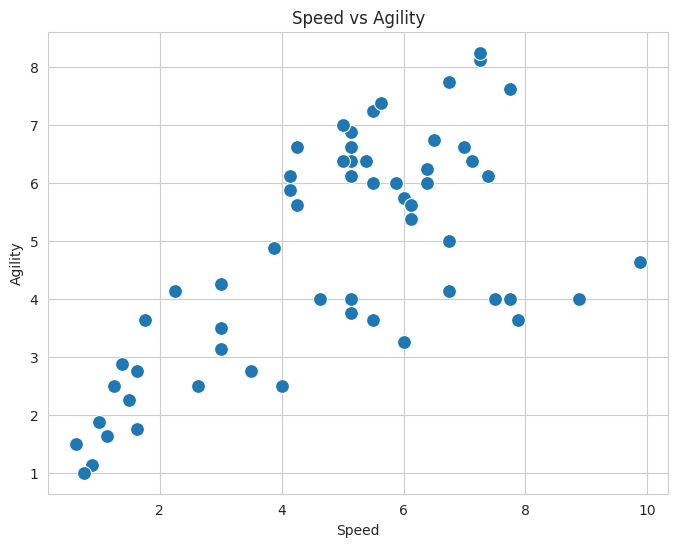

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Speed',
    y='Agility',
    s=100
)

plt.title("Speed vs Agility")

plt.show()

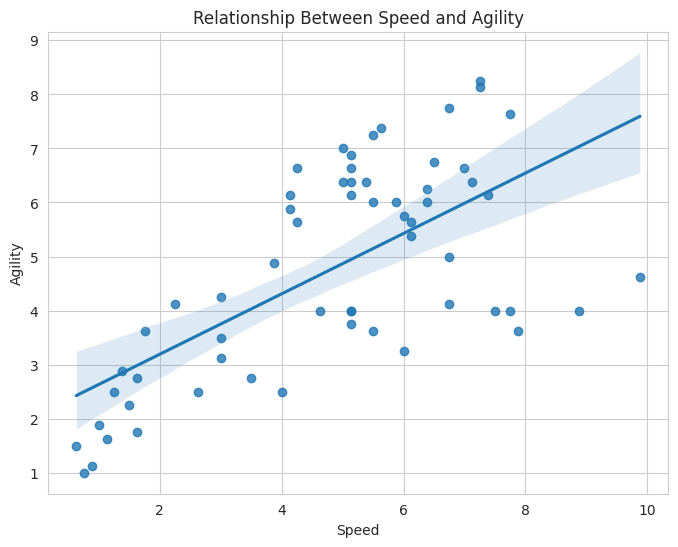

In [14]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='Speed',
    y='Agility'
)

plt.title("Relationship Between Speed and Agility")

plt.show()